## Maze generator

In [62]:
import random

def generate_maze(rows, cols, wall_prob=0.3):
    maze = []
    for r in range(rows):
        row = []
        for c in range(cols):
            if random.random() < wall_prob:
                row.append(0)
            else:
                row.append(1)
        maze.append(row)

# This guarantees the algorithm can at least attempt a path search.
    maze[0][0] = 1
    maze[rows-1][cols-1] = 1
    return maze

In [63]:
def print_maze(maze,path=None):
    path = set(path) if path else set()

    for r in range(len(maze)):
        for c in range(len(maze[0])):
            if (r,c) in path:
                print(" P ", end=" ")
            elif maze[r][c] == 0:
                print(" | ", end=" ")
            else:
                print(" . ", end=" ")
        print()

## DFS on maze

In [64]:
def dfs_on_maze_stack(maze,rows,cols,parent_st,start,end):

    directions = [(-1,0),(0,-1),(1,0),(0,1)]
    st = [start]
    visited_st = {start}

    while st:
        node = st.pop()
        r,c = node

        if (r,c) == end:
            path2 = []
            node2 = (rows-1,cols-1)
            while node2 != start:
                path2.append(node2)
                node2 = parent_st[node2]
            path2.append(start)
            path2.reverse()
            return path2

        for dr,dc in directions:
            newr = r+dr
            newc = c+dc
            
            if 0<=newr<rows and 0<=newc<cols: # considering boundary
                if maze[newr][newc]==1 and (newr,newc) not in visited_st:
                    visited_st.add((newr,newc))
                    st.append((newr,newc))
                    parent_st[(newr,newc)] = (r,c)

In [73]:
def dfs_on_maze_rec(maze,rows,cols,directions,visited,parent,start,end):
    r, c = start
    if (r,c) == end:
        return True

    for dr,dc in directions:
        newr = r + dr
        newc = c + dc

        if 0 <= newr < rows and 0 <= newc < cols:
            if maze[newr][newc] == 1 and (newr,newc) not in visited:
                visited.add((newr,newc))
                parent[(newr,newc)] = (r,c)
                if dfs_on_maze_rec(maze,rows,cols,directions,visited,parent,(newr,newc),end):
                    return True
    return False

## BFS shortest path on maze

In [66]:
from collections import deque

def bfs_shortest_path(maze,start,end):
    rows = len(maze)
    cols = len(maze[0])

    directions = [(-1,0),(1,0),(0,-1),(0,1)] # left,right,up,down

    q = deque([start])
    visited = set([start])
    parent = {}

    while q:
        r,c = q.popleft()

        # termination condition
        if (r,c) == end:
            path = []
            node = end
            while node != start:
                path.append(node)
                node = parent[node]
            path.append(start)
            path.reverse()
            return path


        for dr,dc in directions:
            nr = r + dr
            nc = c + dc

            if 0 <= nr < rows and 0 <= nc < cols: # not outside the maze
                if maze[nr][nc] == 1 and (nr,nc) not in visited: 
                    visited.add((nr,nc))
                    parent[(nr,nc)] = (r,c)
                    q.append((nr,nc))

    return None

## Bi-Directional search

In [67]:
def build_path(start, end, meet, parent_start, parent_end):

    path_start = []
    node = meet

    while node != start:
        path_start.append(node)
        node = parent_start[node]

    path_start.append(start)
    path_start.reverse()

    path_end = []
    node = meet

    while node != end:
        node = parent_end[node]
        path_end.append(node)

    return path_start + path_end

In [ ]:
def bidirectional_bfs(maze,start,end):
    rows = len(maze)
    cols = len(maze[0])

    directions = [(-1,0),(1,0),(0,-1),(0,1)]

    from collections import deque

    # queues
    q_start = deque([start])
    q_end = deque([end])

    # visited sets
    visited_start = {start}
    visited_end = {end}

    # parent dictionaries
    parent_start = {}
    parent_end = {}

    while q_start and q_end:

        # ---- BFS from start side ----
        r,c = q_start.popleft()

        for dr,dc in directions:
            nr = r + dr
            nc = c + dc

            if 0 <= nr < rows and 0 <= nc < cols:
                if maze[nr][nc] == 1 and (nr,nc) not in visited_start:

                    visited_start.add((nr,nc))
                    parent_start[(nr,nc)] = (r,c)
                    q_start.append((nr,nc))

                    # meeting point
                    if (nr,nc) in visited_end:
                        meet = (nr,nc)
                        return build_path(start,end,meet,parent_start,parent_end)


        # ---- BFS from end side ----
        r,c = q_end.popleft()

        for dr,dc in directions:
            nr = r + dr
            nc = c + dc

            if 0 <= nr < rows and 0 <= nc < cols:
                if maze[nr][nc] == 1 and (nr,nc) not in visited_end:

                    visited_end.add((nr,nc))
                    parent_end[(nr,nc)] = (r,c)
                    q_end.append((nr,nc))

                    # meeting point
                    if (nr,nc) in visited_start:
                        meet = (nr,nc)
                        return build_path(start,end,meet,parent_start,parent_end)

    return None

## main function

In [69]:
rows = 12
cols = 12
maze = generate_maze(rows, cols, wall_prob=0.20)
directions = [(-1,0),(0,1),(1,0),(0,-1)]

start = (0,0)
end = (rows-1,cols-1)

In [70]:
# bfs shortest path on maze
path = bfs_shortest_path(maze,start,end)

In [71]:
# dfs using stack
parent_st = {}
path_st = dfs_on_maze_stack(maze,rows,cols,parent_st,start,end)

In [74]:
# dfs using recursion
visited_rec = {start}
parent_rec = {}
dfs_on_maze_rec(maze,rows,cols,directions,visited_rec,parent_rec,start,end)

True

In [75]:
# dfs path construction
path_rec = []
node2 = (rows-1,cols-1)
while node2 != start:
    path_rec.append(node2)
    node2 = parent_rec[node2]
path_rec.append(start)
path_rec.reverse()

In [76]:
# bidirectional bfs
path3 = bidirectional_bfs(maze,start,end)

In [77]:
print("Maze:")
print_maze(maze)

if path:
    print("\nShortest Path Length:", len(path)-1)
    print("\nMaze with shortest path:")
    print_maze(maze, path)

if path_st:
    print("\nMaze with dfs path:")
    print("\ndfs path length:",len(path_st)-1)
    print_maze(maze, path_st)

if path3:
    print("\nMaze with Bidirectional BFS path:")
    print("Bidirectional BFS path length:", len(path3)-1)
    print_maze(maze, path3)
    
else:
    print("\nNo path found")

Maze:
 .   |   .   |   .   |   .   |   .   .   .   .  
 .   .   .   .   .   .   |   .   |   .   .   .  
 |   .   .   |   .   |   .   .   .   .   .   |  
 .   .   .   .   .   .   .   .   .   .   .   .  
 |   .   .   .   |   |   .   .   |   .   .   .  
 .   .   |   |   .   .   .   .   |   .   .   .  
 .   .   |   .   |   .   .   |   .   .   .   .  
 .   .   .   .   .   .   .   .   .   |   |   .  
 .   .   |   .   .   .   .   .   .   .   .   .  
 .   .   .   .   .   .   .   .   .   |   |   .  
 .   |   |   .   .   |   .   |   .   .   .   |  
 |   .   .   .   .   .   .   .   .   .   .   .  

Shortest Path Length: 22

Maze with shortest path:
 P   |   .   |   .   |   .   |   .   .   .   .  
 P   P   .   .   .   .   |   .   |   .   .   .  
 |   P   .   |   .   |   .   .   .   .   .   |  
 .   P   .   .   .   .   .   .   .   .   .   .  
 |   P   .   .   |   |   .   .   |   .   .   .  
 .   P   |   |   .   .   .   .   |   .   .   .  
 .   P   |   .   |   .   .   |   .   .   .   .  
 .   P   . 

In [ ]:
# BFS complexity ≈ O(b^d)
# Bidirectional BFS ≈ O(b^(d/2))

# b = 4
# d = 10
# BFS      = 4^10 = 1,048,576 nodes
# BiBFS    = 2 * 4^5 = 2048 nodes

In [25]:
!pip install networkx matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 278.5 kB/s eta 0:00:00a 0:00:01


In [26]:
import networkx as nx

def maze_to_graph(maze):
    rows = len(maze)
    cols = len(maze[0])

    G = nx.Graph()

    directions = [(-1,0),(1,0),(0,-1),(0,1)]

    for r in range(rows):
        for c in range(cols):

            if maze[r][c] == 1:   # only open cells
                G.add_node((r,c))

                for dr,dc in directions:
                    nr = r + dr
                    nc = c + dc

                    if 0 <= nr < rows and 0 <= nc < cols:
                        if maze[nr][nc] == 1:
                            G.add_edge((r,c),(nr,nc))

    return G

In [27]:
import matplotlib.pyplot as plt

def draw_graph(G, path=None, start=None, end=None):

    pos = {node:(node[1],-node[0]) for node in G.nodes()}

    node_sizes = []
    for node in G.nodes():

        if path and node in path:
            node_sizes.append(400)

        elif node == start or node == end:
            node_sizes.append(500)

        else:
            node_sizes.append(100)

    nx.draw(
        G,
        pos,
        with_labels=False,
        node_size=node_sizes
    )

    plt.show()

In [28]:
G = maze_to_graph(maze)

Graph visualization with BFS path


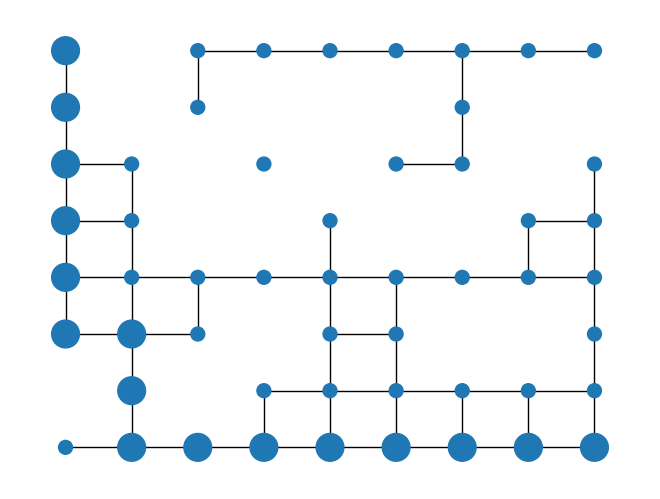

In [29]:
print("Graph visualization with BFS path")
draw_graph(G, path, start, end)

Graph visualization with DFS path


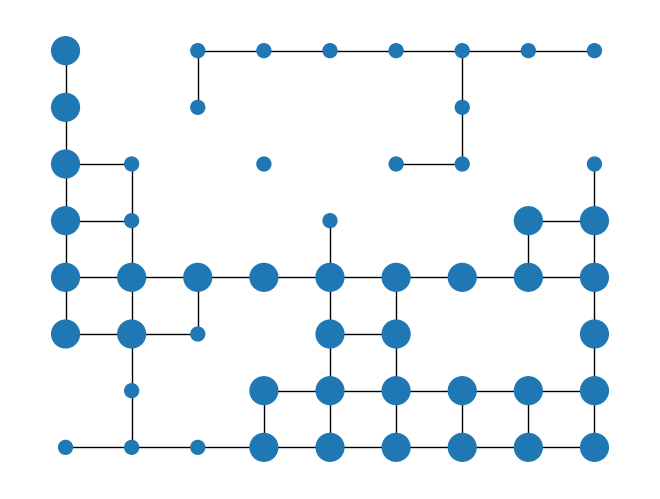

In [30]:
print("Graph visualization with DFS path")
draw_graph(G, path2, start, end)

Graph visualization with Bidirectional BFS path


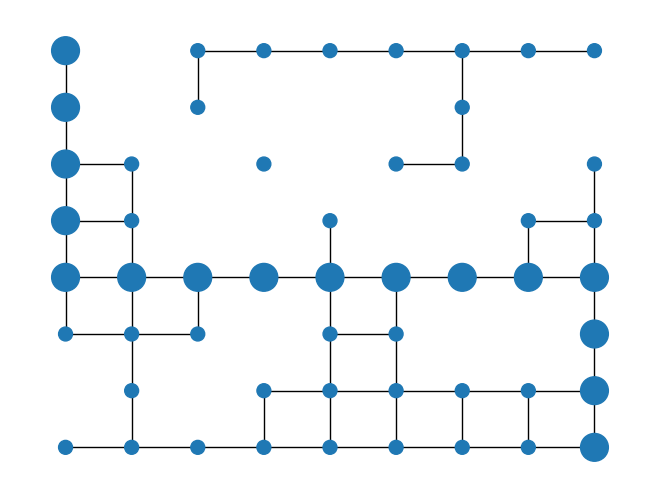

In [31]:
print("Graph visualization with Bidirectional BFS path")
draw_graph(G, path3, start, end)